# Chapter 4b -- The green, social & sustainability (GSS) bond market

Continues [`04a_market_labels_regulation.ipynb`](04a_market_labels_regulation.ipynb)
with the labelled-bond market itself: total green/social/sustainability
issuance, then the green bond market broken down four ways (by
development-market status, region, sector, and issuer type), then the
social bond market broken down three ways (by market, region, and
issuer type). All data is real, sourced from the Climate Bonds
Initiative (CBI) and read directly via `pandas.read_excel`.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


def stacked_issuance_outstanding(data, names, years, title_suffix="", ylim_outstanding=None):
    # `data`: (n_years, n_categories) issuance; cumulative sum gives the
    # outstanding stock. Shared by every CBI issuance/outstanding chart
    # in this notebook (green bond market breakdowns, social bond
    # breakdowns).
    issuance = data
    outstanding = np.cumsum(data, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, d, title in [(axes[0], issuance, f"Issuance ($bn){title_suffix}"),
                          (axes[1], outstanding, f"Outstanding ($bn){title_suffix}")]:
        bottom = np.zeros(len(years))
        for j, name in enumerate(names):
            ax.bar(years, d[:, j], bottom=bottom, label=name)
            bottom += d[:, j]
        ax.set_title(title)
        ax.grid(axis="y")
    if ylim_outstanding is not None:
        axes[1].set_ylim(*ylim_outstanding)
    axes[1].legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    plt.show()

    amount = outstanding[-1]
    freq = 100 * amount / amount.sum()
    return pd.DataFrame({"Category": names, "Outstanding ($bn)": amount.round(0),
                          "Share (%)": freq.round(1)}).sort_values("Outstanding ($bn)", ascending=False)


def load_cbi_sheet(xlsx_name, sheet):
    df = pd.read_excel(f"{DATA_DIR}/{xlsx_name}", sheet_name=sheet, header=None)
    years = df.iloc[0, 1:].dropna().astype(int).values
    names = df.iloc[1:, 0].dropna().tolist()
    data = df.iloc[1:1 + len(names), 1:1 + len(years)].fillna(0).values.astype(float)
    return years, names, data.T  # transpose to (n_years, n_categories)


## 1. Total green, social & sustainability bond issuance

Combined issuance and cumulative outstanding stock of green, social,
and sustainability bonds, 2014-2023, each aggregated across
developed-market, emerging-market, and supranational issuers.

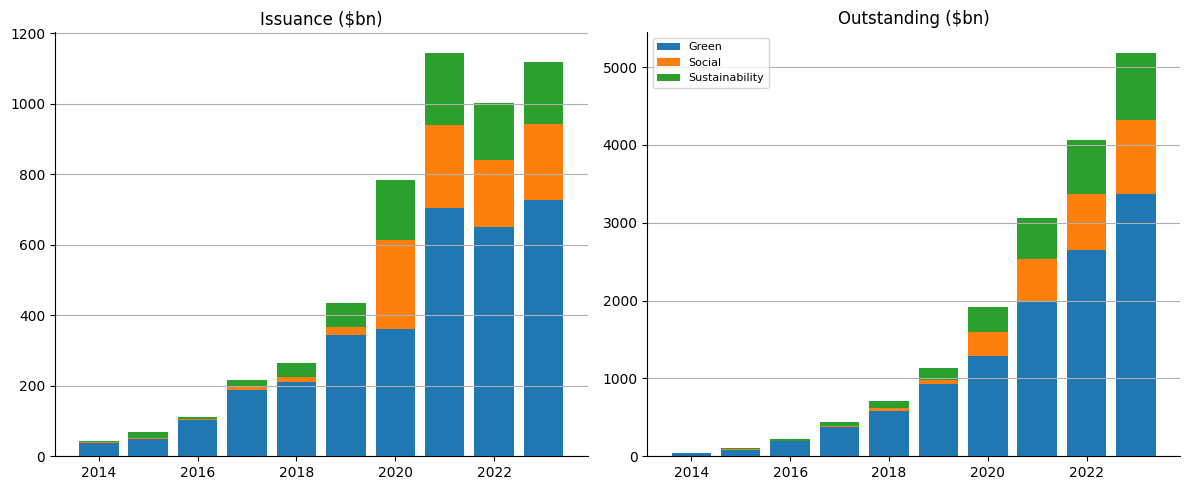

In [2]:

gss = pd.read_excel(f"{DATA_DIR}/chap4_CBI_data1_2023.xlsx", sheet_name=0, header=None)
years = gss.iloc[0, 2:].dropna().astype(int).values
green = gss.iloc[4, 2:2 + len(years)].values.astype(float)            # Green, Total row
social = gss.iloc[8, 2:2 + len(years)].values.astype(float)           # Social, Total row
sustainability = gss.iloc[12, 2:2 + len(years)].values.astype(float)  # Sustainability, Total row

data = np.column_stack([green, social, sustainability])
summary = stacked_issuance_outstanding(data, ["Green", "Social", "Sustainability"], years)


### 1.1 Share of the outstanding market

Each category's share of the total outstanding stock at the end of
the sample.

In [3]:

display(summary)


,Category,Outstanding ($bn),Share (%)
0,Green,3372.0,65.0
1,Social,946.0,18.2
2,Sustainability,870.0,16.8


## 2. The green bond market, four ways

Breaking the green bond market down by development status, region,
sector, and issuer type -- each read from one sheet of
`chap4_CBI_data2_2023.xlsx`. A few breakdowns also have an
end-of-sample outstanding-share table version instead of just a chart;
the tables are folded into the same helper call here
(`stacked_issuance_outstanding` already returns one).

### 2.1 By market status (developed / emerging / supranational)

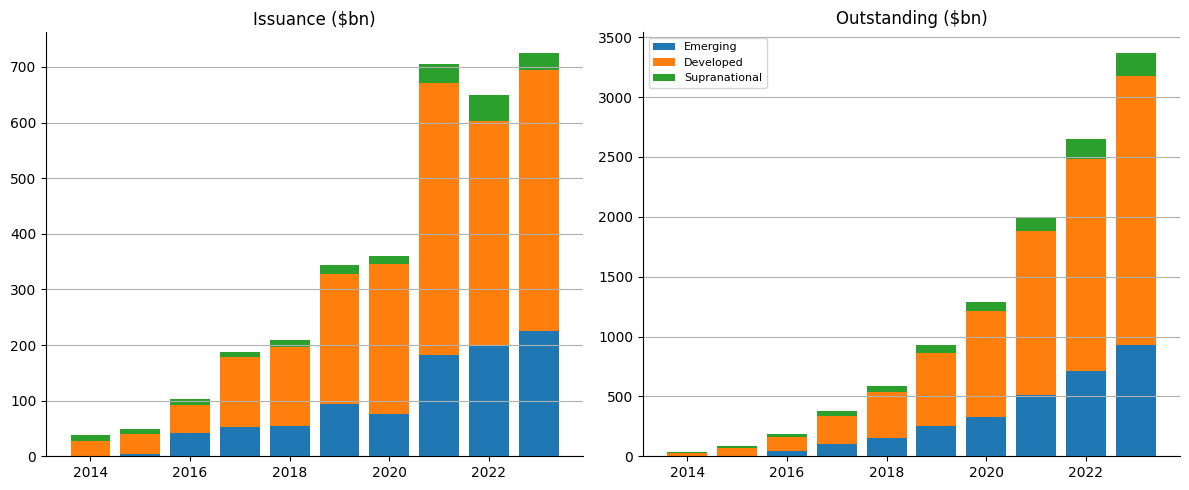

,Category,Outstanding ($bn),Share (%)
1,Developed,2244.0,66.6
0,Emerging,933.0,27.7
2,Supranational,194.0,5.8


In [4]:

years, names, data = load_cbi_sheet("chap4_CBI_data2_2023.xlsx", "GB1")
t1 = stacked_issuance_outstanding(data, names, years)
display(t1)


### 2.2 By region

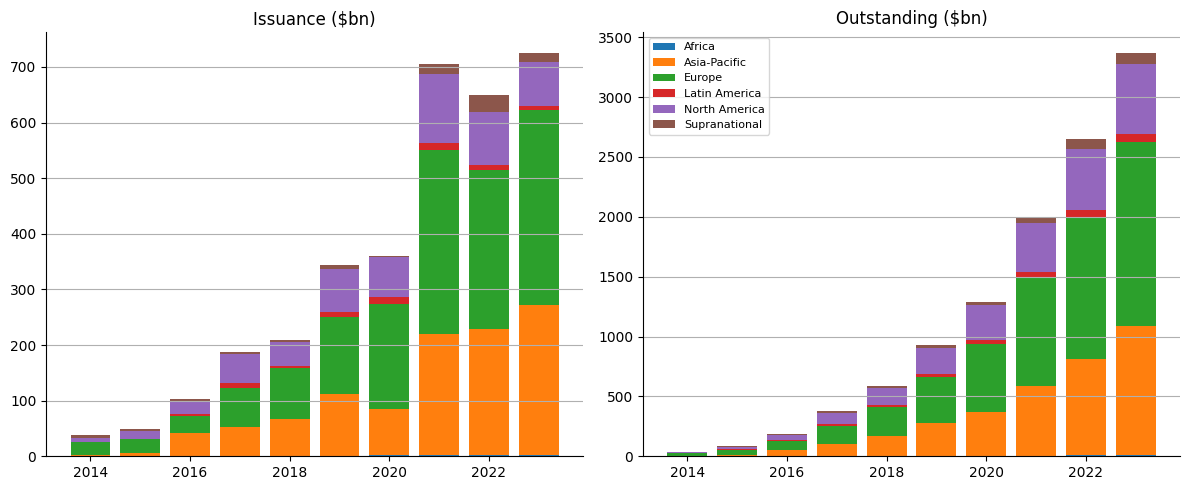

,Category,Outstanding ($bn),Share (%)
2,Europe,1536.0,45.6
1,Asia-Pacific,1076.0,31.9
4,North America,588.0,17.4
5,Supranational,94.0,2.8
3,Latin America,67.0,2.0
0,Africa,11.0,0.3


In [5]:

years, names, data = load_cbi_sheet("chap4_CBI_data2_2023.xlsx", "GB2")
t2 = stacked_issuance_outstanding(data, names, years)
display(t2)


### 2.3 By sector

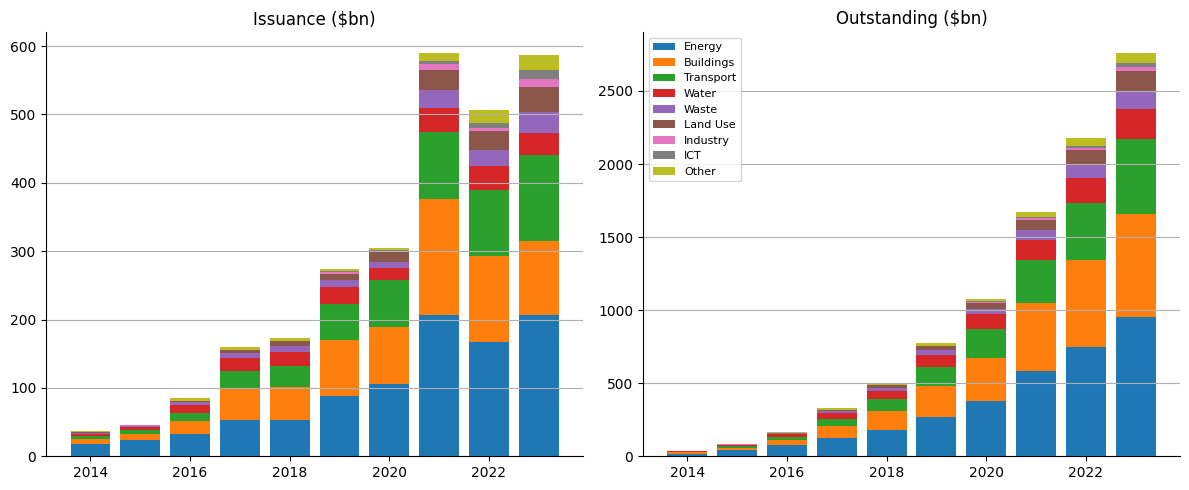

,Category,Outstanding ($bn),Share (%),Cumulative share (%)
0,Energy,955.0,34.6,34.6
1,Buildings,701.0,25.4,60.0
2,Transport,519.0,18.8,78.8
3,Water,205.0,7.4,86.2
5,Land Use,136.0,4.9,91.1
4,Waste,118.0,4.3,95.4
8,Other,73.0,2.6,98.0
6,Industry,29.0,1.0,99.0
7,ICT,29.0,1.0,100.0


In [6]:

years, names, data = load_cbi_sheet("chap4_CBI_data2_2023.xlsx", "GB3")
t3 = stacked_issuance_outstanding(data, names, years)
display(t3.assign(**{"Cumulative share (%)": t3["Share (%)"].cumsum().round(1)}))


### 2.4 By issuer type

The second issuer-type category is renamed from its raw sheet label
to "Gov/Sov".

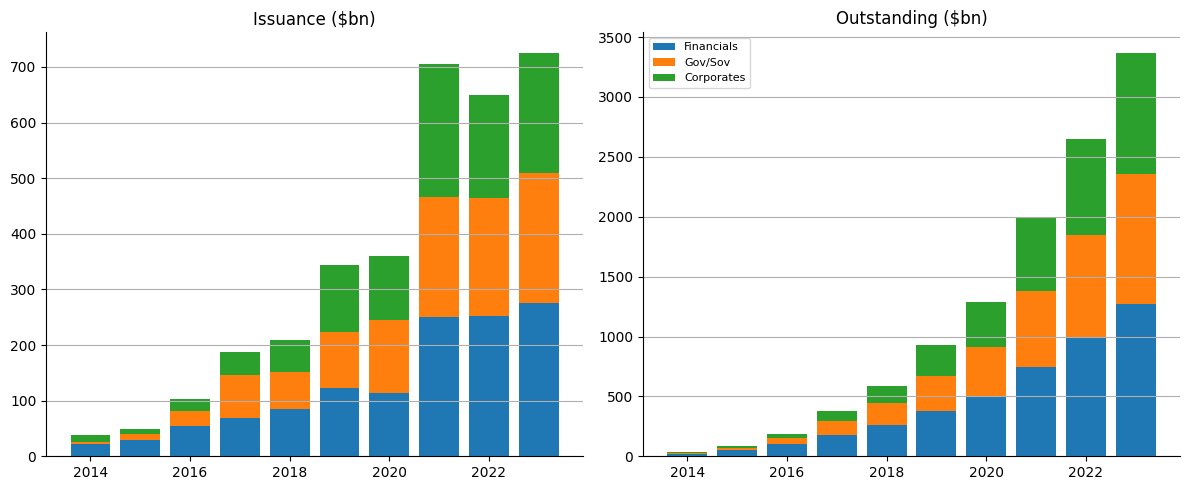

,Category,Outstanding ($bn),Share (%),Cumulative share (%)
0,Financials,1273.0,37.8,37.8
1,Gov/Sov,1081.0,32.1,69.9
2,Corporates,1017.0,30.2,100.1


In [7]:

years, names, data = load_cbi_sheet("chap4_CBI_data2_2023.xlsx", "GB5")
names[1] = "Gov/Sov"
t4 = stacked_issuance_outstanding(data, names, years)
display(t4.assign(**{"Cumulative share (%)": t4["Share (%)"].cumsum().round(1)}))


## 3. The social bond market, three ways

Breaking the social bond market down by market status, region, and
(two granularities of) issuer type -- read from
`chap4_CBI_data4_2023.xlsx`.

### 3.1 By market status

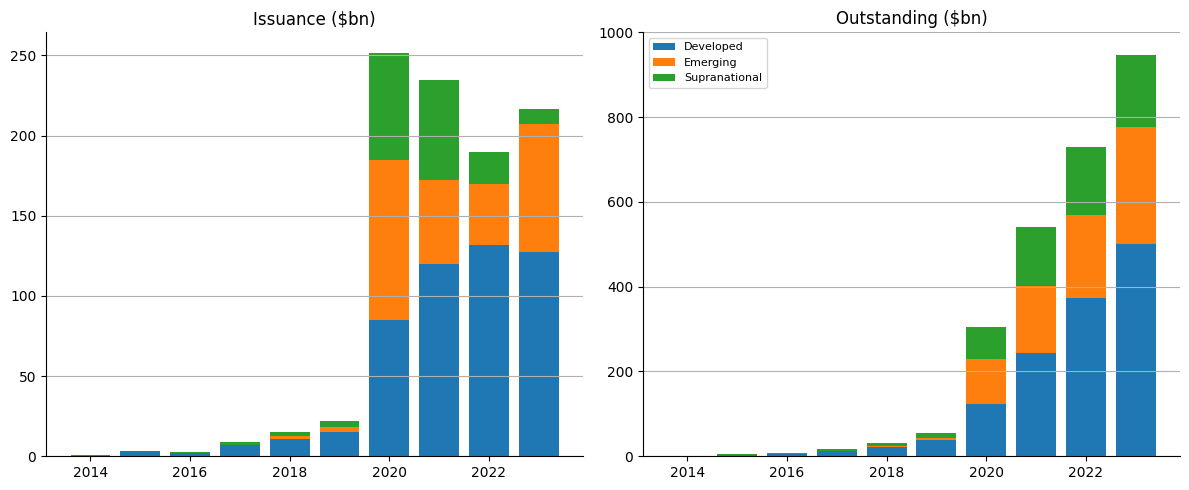

,Category,Outstanding ($bn),Share (%)
0,Developed,502.0,53.0
1,Emerging,276.0,29.1
2,Supranational,169.0,17.9


In [8]:

years, names, data = load_cbi_sheet("chap4_CBI_data4_2023.xlsx", "Market")
t5 = stacked_issuance_outstanding(data, names, years, ylim_outstanding=(0, 1000))
display(t5)


### 3.2 By region

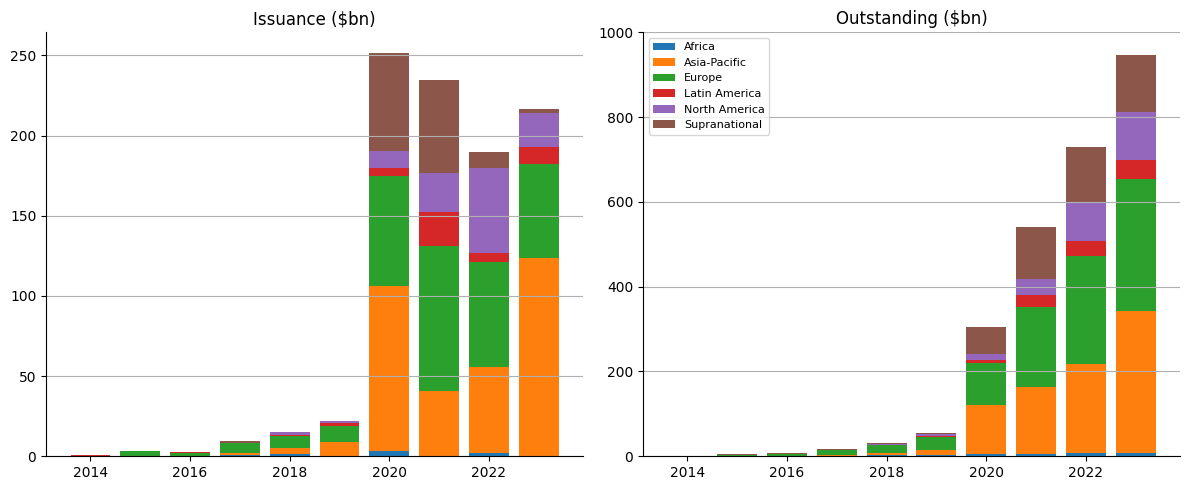

,Category,Outstanding ($bn),Share (%)
1,Asia-Pacific,334.0,35.2
2,Europe,312.0,33.0
5,Supranational,134.0,14.2
4,North America,112.0,11.9
3,Latin America,45.0,4.8
0,Africa,8.0,0.9


In [9]:

years, names, data = load_cbi_sheet("chap4_CBI_data4_2023.xlsx", "Region")
t6 = stacked_issuance_outstanding(data, names, years, ylim_outstanding=(0, 1000))
display(t6)


### 3.3 By issuer type, simplified (4 categories)

The `Type` sheet carries two issuer-type classifications stacked in
one sheet -- a detailed 7-category one and a simplified 4-category
roll-up (Corporates/Financials/Gov-sov/Other). This section uses the
simplified roll-up.

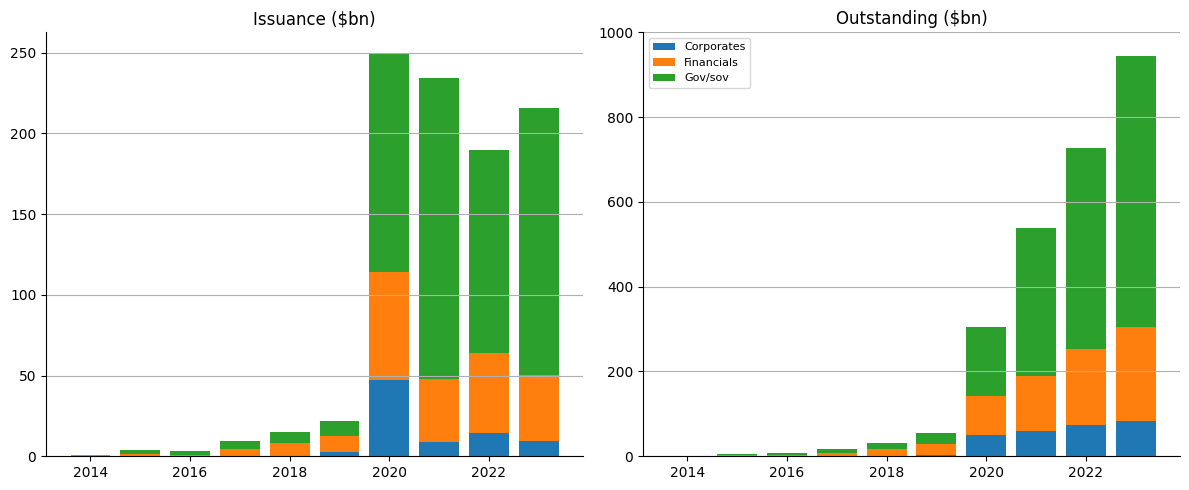

,Category,Outstanding ($bn),Share (%)
2,Gov/sov,640.0,67.8
1,Financials,221.0,23.4
0,Corporates,83.0,8.8


In [10]:

type_sheet = pd.read_excel(f"{DATA_DIR}/chap4_CBI_data4_2023.xlsx", sheet_name="Type", header=None)
years_type = type_sheet.iloc[0, 1:].dropna().astype(int).values
simple_names = type_sheet.iloc[8:11, 0].tolist()  # rows 8-10 (0-indexed): Corporates, Financials, Gov/sov
simple_data = type_sheet.iloc[8:11, 1:1 + len(years_type)].fillna(0).values.astype(float).T

t7 = stacked_issuance_outstanding(simple_data, simple_names, years_type, ylim_outstanding=(0, 1000))
display(t7)


### 3.4 By issuer type, detailed (7 categories)

The detailed classification from the same `Type` sheet (rows 1-7):
Corporates, Development Bank, Financials, Government-Backed Entity,
Local Government, Other, Sovereign.

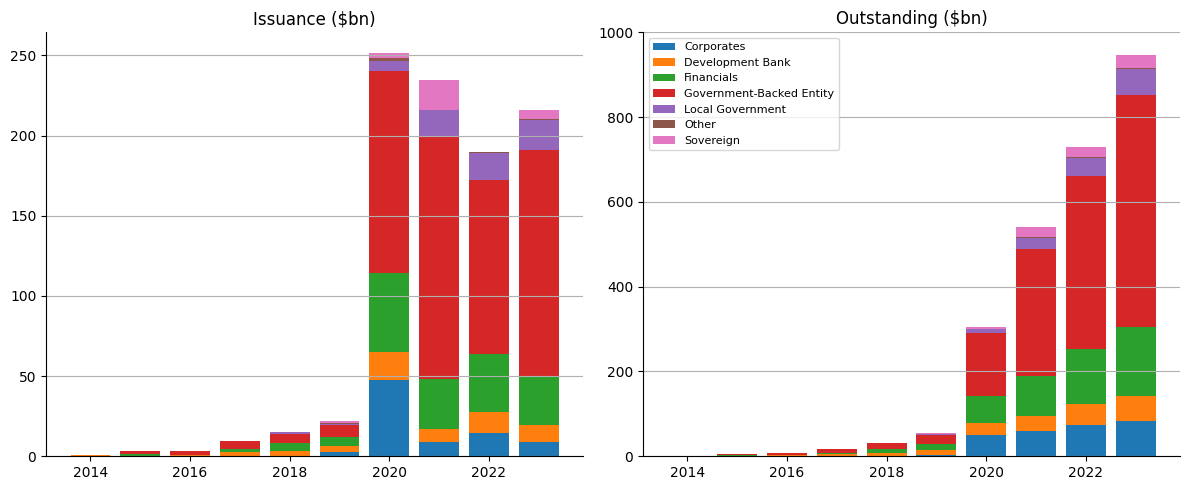

,Category,Outstanding ($bn),Share (%)
3,Government-Backed Entity,549.0,58.0
2,Financials,161.0,17.0
0,Corporates,83.0,8.8
4,Local Government,61.0,6.5
1,Development Bank,60.0,6.4
6,Sovereign,30.0,3.1
5,Other,3.0,0.3


In [11]:

detailed_names = type_sheet.iloc[1:8, 0].tolist()
detailed_data = type_sheet.iloc[1:8, 1:1 + len(years_type)].fillna(0).values.astype(float).T

t8 = stacked_issuance_outstanding(detailed_data, detailed_names, years_type, ylim_outstanding=(0, 1000))
display(t8)
